In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/student_performance_cleaned.csv")
df

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
0,1,Ali,M,16,5,90,9,75,72,80,77.5,8,Very Good
1,2,Ahmed,M,15,3,70,6,55,60,58,56.5,-2,Needs Improvement
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good
4,5,Usman,M,16,2,65,5,48,52,50,49.0,-2,Needs Improvement
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
6,7,Bilal,M,16,4,80,7,65,68,72,68.5,4,Good
7,8,Zain,M,15,3,75,6,58,62,65,61.5,3,Average
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
9,10,Hassan,M,15,1,55,4,40,45,42,41.0,-3,At Risk


In [4]:
# Top 5 students by Final marks
top_students = df.sort_values(
    by="Final",
    ascending=False
).head(7)
top_students

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
15,16,Mubashar,M,20,7,80,10,70,85,98,84.0,13,Excellent
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
14,15,Eman,F,16,8,97,10,90,91,94,92.0,3,Excellent
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
12,13,Noor,F,16,7,93,9,86,84,89,87.5,5,Very Good
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good


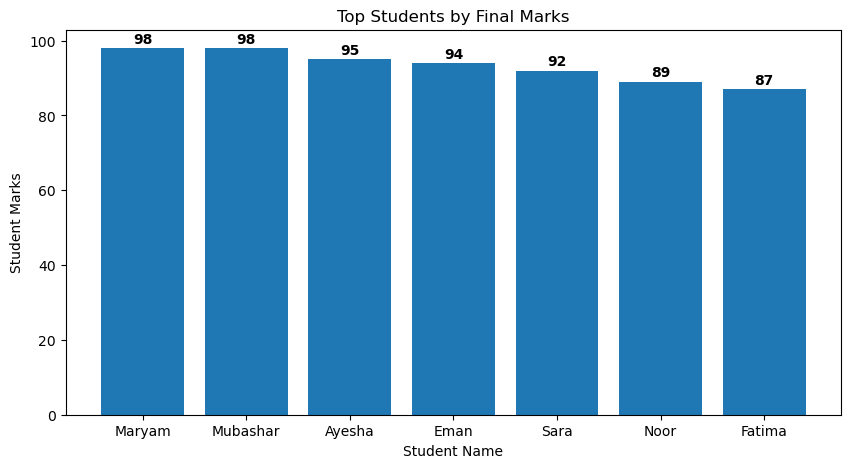

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(top_students["Name"], top_students["Final"])
plt.title("Top Students by Final Marks")
plt.xlabel("Student Name")
plt.ylabel("Student Marks")
# Add this code right before plt.show()
for index, value in enumerate(top_students["Final"]):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontweight='bold')
plt.show()

In [6]:
# Average Final marks by gender
average_marks_by_gender = df.groupby("Gender")['Final'].mean().map('{: .2f}%'.format)
average_marks_by_gender

Gender
F     91.00%
M     65.89%
Name: Final, dtype: object

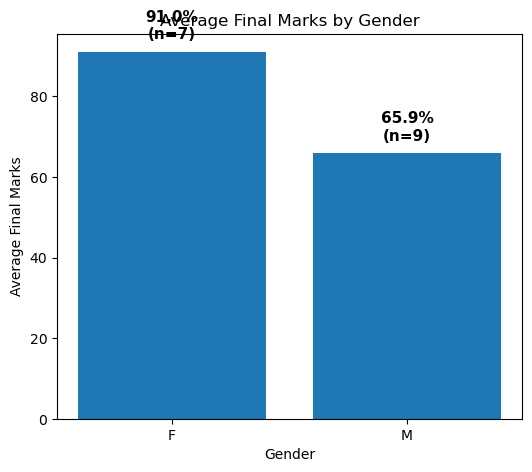

In [18]:
avg_gender = df.groupby("Gender")["Final"].mean()

plt.figure(figsize=(6,5))
plt.bar(avg_gender.index, avg_gender.values)
# 3. ADD PERCENTAGE LABELS ON TOP OF EACH BAR (NEW CODE)
# Loop through each bar's index and its value
#for i, v in enumerate(avg_gender.values):
    # Place text at (x=i, y=v+0.5) with formatting as "91.0%"
    # ha='center' keeps it centered, va='bottom' places it above the bar
    #plt.text(i, v + 0.5, f"{v:.1f}%", 
             #ha='center', va='bottom', fontweight='bold', fontsize=12)
# Get the count of students per gender
count_gender = df.groupby("Gender")["Final"].count()

for i, (avg, count) in enumerate(zip(avg_gender.values, count_gender.values)):
    plt.text(i, avg + 2.5, f"{avg:.1f}%\n(n={count})", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title("Average Final Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Marks")

plt.show()

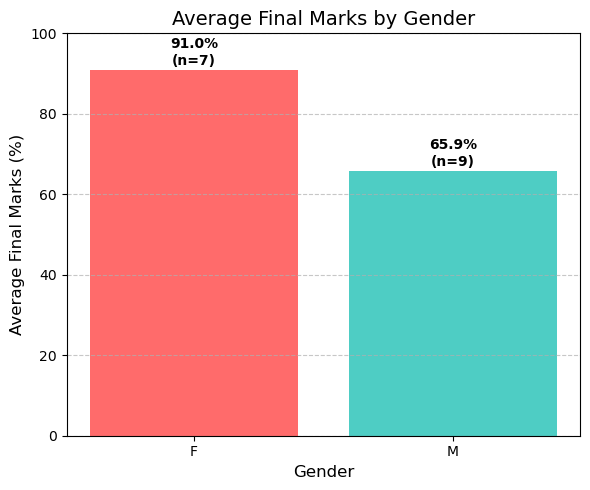

In [20]:
# 1. GROUP AGGREGATION: Compute mean and count per gender
avg_gender = df.groupby("Gender")["Final"].mean()
count_gender = df.groupby("Gender")["Final"].count()

# 2. CREATE THE PLOT
fig, ax = plt.subplots(figsize=(6,5))

# Draw the bars with distinct colors
bars = ax.bar(avg_gender.index, avg_gender.values, color=['#FF6B6B', '#4ECDC4'])  # coral and teal

# 3. ADD LABELS: Percentage + (n=count) on top of each bar
for bar, avg, count in zip(bars, avg_gender.values, count_gender.values):
    # Format the label as "91.0%\n(n=7)"
    label = f"{avg:.1f}%\n(n={count})"
    # Place the label at the bar's center, slightly above the top
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            label, ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. FORMATTING
ax.set_title("Average Final Marks by Gender", fontsize=14)
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Average Final Marks (%)", fontsize=12)
ax.set_ylim(0, 100)  # scores are percentages out of 100
ax.grid(axis='y', linestyle='--', alpha=0.7)  # optional horizontal grid

# 5. DISPLAY
plt.tight_layout()
plt.show()